<a href="https://colab.research.google.com/github/Anshu-kumar-singh/6-Basic-ML-Projects/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer_Segmentation

In [35]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings('ignore')

In [36]:
# Cell 2: Load Dataset
df = pd.read_csv("https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv")
# Check number of rows and columns
print(df.shape)
df.head()

(200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [38]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

* i added gender and age and thought it will inc the clustering but it eventually reduced it
* how i got to know => Silhouette Scores (cell 6 ) it tell about how good is your clustering but when i added age and gender it droped

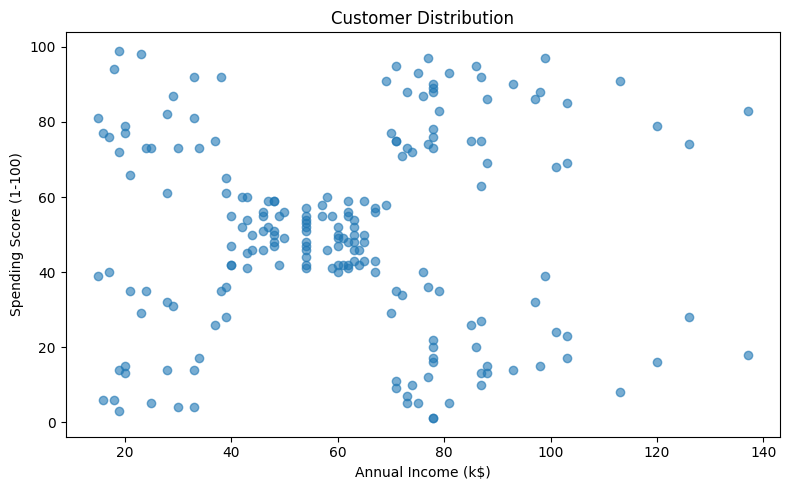

In [39]:
# Cell 3: Visualize Raw Data
plt.figure(figsize=(8, 5))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    alpha=0.6
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Distribution')

plt.tight_layout()
plt.show()

In [40]:
# Cell 4: Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

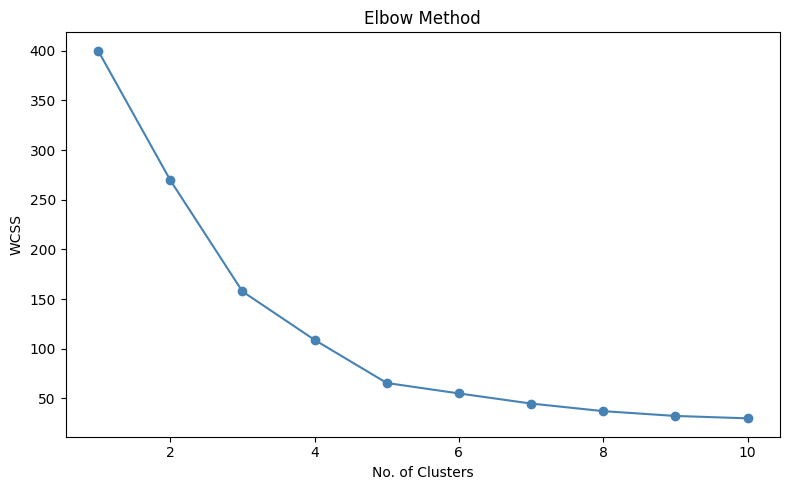

In [41]:
# Cell 5: Elbow Method
wcss = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o',
    color='steelblue'
)

plt.title('Elbow Method')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')

plt.tight_layout()
plt.show()

In [42]:
# Cell 6: Silhouette Scores
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)

    label = km.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, label)

    print(f"Silhouette Score for K={k}: {score:.2f}")

Silhouette Score for K=2: 0.32
Silhouette Score for K=3: 0.47
Silhouette Score for K=4: 0.49
Silhouette Score for K=5: 0.55
Silhouette Score for K=6: 0.54


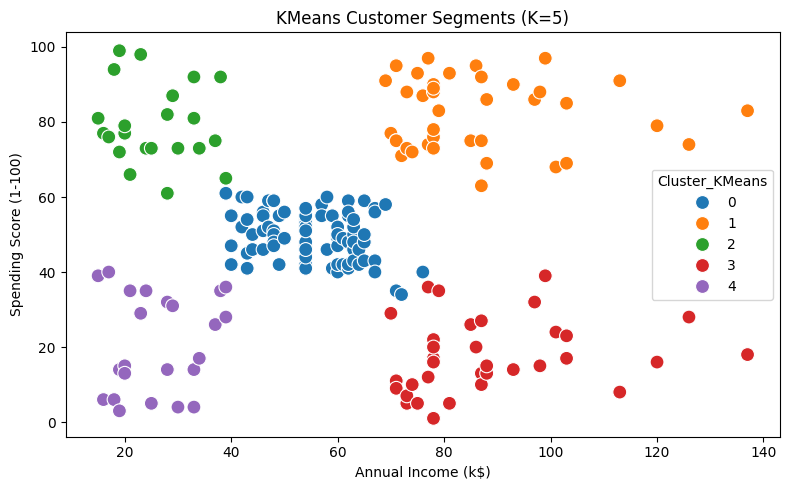

In [43]:
# Cell 7: KMeans Clustering with K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster_KMeans',
    data=df,
    palette='tab10',
    s=100
)

plt.title('KMeans Customer Segments (K=5)')

plt.tight_layout()
plt.show()

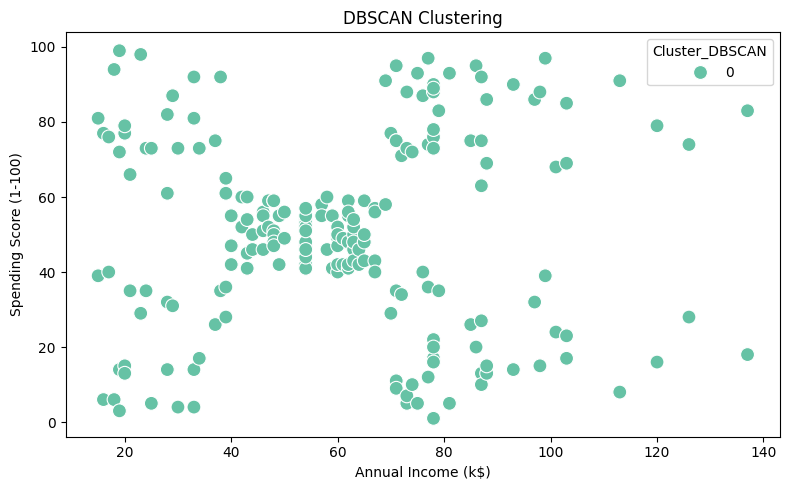

In [44]:
# Cell 8: DBSCAN Clustering
db = DBSCAN(eps=0.8, min_samples=5)

df['Cluster_DBSCAN'] = db.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster_DBSCAN',
    data=df,
    palette='Set2',
    s=100
)

plt.title('DBSCAN Clustering')

plt.tight_layout()
plt.show()

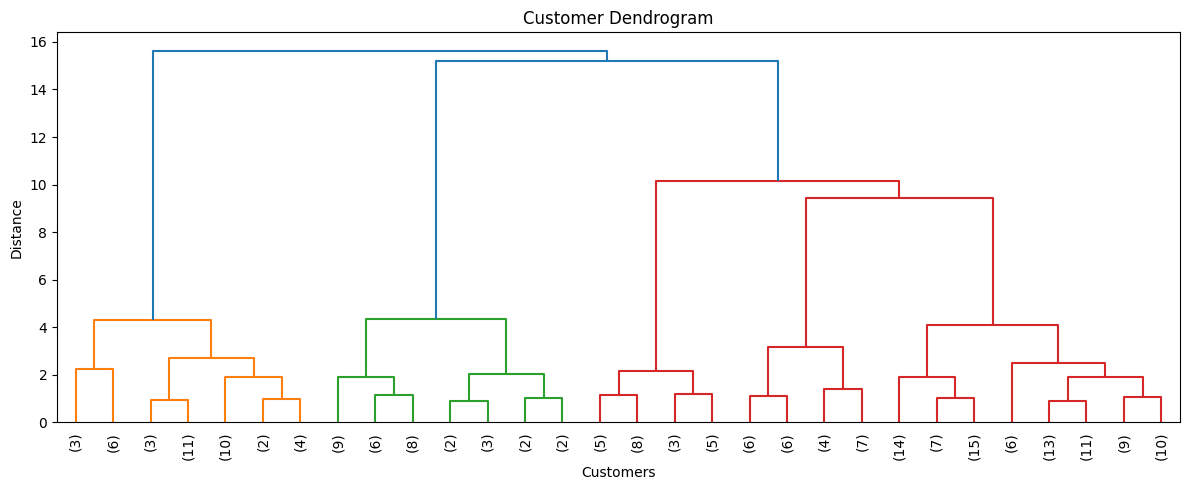

In [45]:
# Cell 9: Dendrogram
link = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))

dendrogram(
    link,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90
)

plt.title('Customer Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')

plt.tight_layout()
plt.show()

In [46]:
# Cell 10: Completion Message
print("Done! All graphs displayed successfully.")

Done! All graphs displayed successfully.


# Customer Segmentation using Clustering – Explanation

## Introduction

This project performs **Customer Segmentation** using different clustering techniques in Machine Learning.

Customer segmentation means dividing customers into groups based on similar behavior.
In this dataset, customers are grouped using:

* **Annual Income**
* **Spending Score**

The goal is to identify patterns such as:

* High income & high spending customers
* Low income & low spending customers
* Careful spenders
* Target customers for marketing

The clustering algorithms used are:

1. KMeans Clustering
2. DBSCAN Clustering
3. Hierarchical Clustering (Dendrogram)

---

# Cell 1 – Import Libraries

In this cell, all required Python libraries are imported.

### Main Libraries Used

* `pandas` → Used for handling datasets
* `numpy` → Used for numerical operations
* `matplotlib` → Used for plotting graphs
* `seaborn` → Used for attractive visualizations
* `KMeans` → Clustering algorithm
* `DBSCAN` → Density-based clustering algorithm
* `StandardScaler` → Feature scaling
* `silhouette_score` → Measures clustering quality
* `dendrogram` and `linkage` → Used for hierarchical clustering

Warnings are ignored to keep the output clean.

---

# Cell 2 – Load Dataset

The dataset is loaded from a CSV file using `pd.read_csv()`.

### Dataset Used

Mall Customers Dataset

### Selected Features

Only two columns are selected:

1. Annual Income (k$)
2. Spending Score (1-100)

These two features are stored in variable `X`.

### Why only these two?

Because they clearly show customer purchasing behavior and make clustering easier to visualize in 2D graphs.

---

# Cell 3 – Visualize Raw Data

A scatter plot is created to visualize customer distribution before clustering.

### X-axis

Annual Income

### Y-axis

Spending Score

### Purpose

This graph helps us understand:

* Whether natural groups already exist
* Customer behavior distribution
* Possible clusters visually

At this stage, all points are the same color because clustering has not been applied yet.

---

# Cell 4 – Feature Scaling

Feature scaling is performed using `StandardScaler`.

### Why scaling is necessary?

Income and spending score may have different ranges.

Machine learning algorithms perform better when:

* Features are normalized
* Values are on similar scales

### What happens?

The scaler converts data so that:

* Mean becomes approximately 0
* Standard deviation becomes 1

The scaled data is stored in `X_scaled`.

---

# Cell 5 – Elbow Method

The Elbow Method helps determine the optimal number of clusters for KMeans.

### Process

KMeans is run multiple times with:

* K = 1 to 10

For each K:

* WCSS (Within Cluster Sum of Squares) is calculated

### What is WCSS?

WCSS measures:

* Distance between data points and cluster centroids

Lower WCSS means:

* Better clustering

### Elbow Concept

The graph usually bends like an elbow.

The bend point indicates:

* Best number of clusters

In this dataset, the elbow is usually around:
K = 5

---

# Cell 6 – Silhouette Scores

Silhouette Score measures clustering quality.

### Score Range

* Close to +1 → Good clustering
* Around 0 → Overlapping clusters
* Negative → Poor clustering

### Purpose

This step validates whether the chosen K value is good.

Higher silhouette score means:

* Better separated clusters

---

# Cell 7 – KMeans Clustering

KMeans clustering is applied using:
K = 5

### What KMeans Does

1. Randomly creates centroids
2. Assigns customers to nearest centroid
3. Updates centroid positions
4. Repeats until stable

### Result

Each customer gets a cluster label:

* Cluster 0
* Cluster 1
* Cluster 2
* etc.

### Visualization

The scatter plot now shows:

* Different customer groups in different colors

### Business Meaning

Possible groups:

* High income & high spending
* High income & low spending
* Low income & high spending
* Average customers

This helps businesses target customers effectively.

---

# Cell 8 – DBSCAN Clustering

DBSCAN is another clustering algorithm.

### Full Form

Density-Based Spatial Clustering of Applications with Noise

### How It Works

Instead of fixed cluster counts:

* It groups nearby dense points
* Detects outliers automatically

### Parameters

#### eps

Maximum distance between neighboring points

#### min_samples

Minimum points needed to form a dense region

### Special Feature

DBSCAN can identify:

* Noise points
* Outliers

These may appear with label:
-1

### Advantage

Unlike KMeans:

* No need to specify number of clusters manually

---

# Cell 9 – Dendrogram

Hierarchical clustering visualization is created using a dendrogram.

### What is Hierarchical Clustering?

It builds clusters step-by-step:

* Closest points merge first
* Larger clusters form gradually

### Dendrogram

A tree-like structure showing:

* Cluster merging process

### Interpretation

Large vertical gaps indicate:

* Good places to cut clusters

This helps estimate the ideal number of clusters visually.

---

# Cell 10 – Completion Message

This cell simply prints:
“Done! All graphs displayed successfully.”

It confirms:

* Code executed properly
* All visualizations were generated

---

# Final Conclusion

This project demonstrates multiple clustering techniques for customer segmentation.

### Techniques Compared

| Algorithm               | Main Idea                    |
| ----------------------- | ---------------------------- |
| KMeans                  | Distance-based clustering    |
| DBSCAN                  | Density-based clustering     |
| Hierarchical Clustering | Tree-based cluster formation |

### Key Learning Outcomes

* Understanding customer behavior
* Finding hidden patterns in data
* Choosing optimal clusters
* Comparing clustering algorithms
* Visualizing customer segments

### Real-World Applications

* Marketing campaigns
* Customer targeting
* Personalized recommendations
* Retail analytics
* Business intelligence

This project is a strong beginner-to-intermediate Machine Learning clustering project and demonstrates practical unsupervised learning concepts effectively.
